# Training a Computer Vision Model for Historical Newspaper Layout

For training a  I have annotated 508 pages of "Die Bombe" with the Annotation Tool [Label Studio](https://labelstud.io/) and created a validation set consisting of 106 pages not contained in the training data.

##Time-period of the periodical
The periodical was publicated in vienna over a 50 year period (1871-1925), with issues appearing once per week in the starting period until a fade-out in mid-1917, where it started to be published three times a month, then only two times per month in 1920 and once per month at the end of 1923 until it's last publication on the 01.02.1925.

##Training and Validation Data
As I have had the chance to get an overview of the periodical before the start of my masters thesis, I already had a chance to get a slight visual impression on which time-period contained the recurring characters I was interested in. Most of them seemed to be contained in the issues before 1900. For this reason I gathered issues from the periods 1871 till 1900, which make up 2/3 of the training data, while 1/3 consists of issues taken from the period of 1900 till 1925. The same treatment was used for approaching the gathering of validation data, which does not overlap with the training data.

##Annotation of the Datasets
The datasets were annotated according to the lables used by the [Newspaper Navigator](https://labs.loc.gov/work/experiments/newspaper-navigator/) Model of the Chronicling America Project conducted by the Library of Congress.

The labels are the following:
 - 0: Advertisement
 - 1: Comic
 - 2: Editorial Cartoon
 - 3: Headline
 - 4: Illustration
 - 5: Map
 - 6: Photograph

 For annotation BoundinBoxes were used instead of polygone regions and for training the annotated data was importet in COCO-format.

 For further explanations on the annotation scheme please review the paper of the Newspaper Navigator and my GitHub for further adjustements done by myself.


## 0) GPU & Environment Sanity Check

In [1]:
# =========================
# (0) Install (Colab) + Restart Runtime
# =========================
# IMPORTANT:
# If you uninstall/reinstall torch/torchvision in the same session,
# you MUST restart the runtime afterwards (Runtime -> Restart runtime).
# After restart, run the notebook from the top again.

!pip -q install -U matplotlib opencv-python pycocotools
!pip -q uninstall -y torch torchvision torchaudio

# Pick ONE torch install line that matches your Colab CUDA (T4 commonly works with cu121)
!pip -q install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121

# Ultralytics (pinned for reproducibility)
!pip -q install ultralytics==8.2.0

import torch, ultralytics
print("torch:", torch.__version__)
print("ultralytics:", ultralytics.__version__)

# Reminder for restarting the runtime
print("✅ Installed/updated packages. Please restart the runtime ONCE: Runtime → Restart runtime, then run from the top.")


torch: 2.4.1+cu121
ultralytics: 8.2.0
✅ Installed/updated packages. Please restart the runtime ONCE: Runtime → Restart runtime, then run from the top.


In [2]:
# Checking whether GPU is accesible
!nvidia-smi || true

import torch, platform
print("torch:", torch.__version__, "cuda available?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
print(platform.platform())


Fri Feb 20 08:01:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1) Install Dependencies and Import from libraries

In [3]:
# =========================
# (1) Imports (run AFTER you restarted the runtime)
# =========================
from google.colab import drive
import os, json, collections, random
import numpy as np
import torch, ultralytics
from pathlib import Path
from datetime import datetime
import platform, hashlib, json
from IPython.display import Image, display


print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("ultralytics:", ultralytics.__version__)


torch: 2.4.1+cu121 | cuda: True
ultralytics: 8.2.0


## 2) Mount Google Drive & Set Project Paths
Adjust `PROJECT_DIR` to match your directory structure. Data contained in the "dataset" directoriy containing training and validations sets should be structured as follows:

```
  images/
    train/   # 508 training page images
    val/     # 106 validation page images
  annotations/
    instances_train.json
    instances_val.json
  labels/
    train/   # 508 txt-files
    val/     # 106 txt-files
```


In [4]:
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models"
WEIGHTS_DIR = f"{PROJECT_DIR}/weights"
DATASET_DIR = f"{PROJECT_DIR}/training_dataset"

# Create folders if missing
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("WEIGHTS_DIR:", WEIGHTS_DIR)


Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models
DATASET_DIR: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset
WEIGHTS_DIR: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/weights


## 3) Create or load `data.yaml` for Ultralytics
YOLOv8 will automatically find COCO annotations if they are named `instances_train.json` and `instances_val.json` inside `annotations/`. Category-names can be specified to lock ordering.

In [5]:
DATA_YAML_PATH = Path(PROJECT_DIR) / "data.yaml"

DATA_YAML = f"""
path: {DATASET_DIR}
train: images/train
val: images/val
names:
  0: Advertisement
  1: Comic
  2: Editorial Cartoon
  3: Headline
  4: Illustration
  5: Map
  6: Photograph
"""

if DATA_YAML_PATH.exists():
    print(f"✅ data.yaml already exists at: {DATA_YAML_PATH}")
else:
    DATA_YAML_PATH.write_text(DATA_YAML.strip() + "\n")
    print(f"🆕 Created new data.yaml at: {DATA_YAML_PATH}")

print("\n--- data.yaml content ---")
print(DATA_YAML_PATH.read_text())


✅ data.yaml already exists at: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/data.yaml

--- data.yaml content ---
path: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset
train: images/train
val: images/val
names:
  0: Advertisement
  1: Comic
  2: Editorial Cartoon
  3: Headline
  4: Illustration
  5: Map
  6: Photograph



In [6]:
print(torch.__version__)
print(ultralytics.__version__)

2.4.1+cu121
8.2.0


## 4) COCO Sanity Check
 - this cell helps catch mismatches of categories early
 - it also shows the count of the instances which I annotated in my training set

In [7]:
train_json_path = os.path.join(DATASET_DIR, "annotations", "instances_train.json")
if not os.path.exists(train_json_path):
    raise FileNotFoundError(f"Missing {train_json_path}. Please place your COCO JSON there.")

with open(train_json_path, "r") as f:
    train_json = json.load(f)

cats = {c["id"]: c["name"] for c in train_json.get("categories", [])}
counts = collections.Counter(a["category_id"] for a in train_json.get("annotations", []))

print("Classes (id->name):", cats)
print("Instances per class:")
for cid, cnt in counts.items():
    print(f"  {cid} ({cats.get(cid, 'UNKNOWN')}): {cnt}")


Classes (id->name): {0: 'Advertisement', 1: 'Comic', 2: 'Editorial Cartoon', 3: 'Headline', 4: 'Illustration', 5: 'Map', 6: 'Photograph'}
Instances per class:
  4 (Illustration): 465
  3 (Headline): 1471
  2 (Editorial Cartoon): 140
  1 (Comic): 61
  0 (Advertisement): 2596
  6 (Photograph): 1


## 5) (Optional) Reproducibility Seeds
Setting a reproducibility seed synchronizes the pseudo-random number generators used during training. This ensures that weight initialization, data shuffling, and stochastic augmentations follow the same deterministic sequence. Consequently, when running this notebook with the same annotated dataset, hyperparameters, and hardware setup, one gets (almost) identical training metrics.

In [8]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seeds set to", SEED)


Seeds set to 42


## 6) Load a Pretrained YOLOv8 Model
Model used for training: 'yolov8m.pt'

In [9]:
from ultralytics.nn.tasks import DetectionModel
from torch.nn.modules.container import Sequential
torch.serialization.add_safe_globals([DetectionModel, Sequential])

## 7) Train on T4 (Colab-friendly settings)
- `imgsz=1280` suits high-res newspapers; reduce to `1024` or `batch` to avoid OOM.
- Keep `workers` low in Colab.
- We set `project`/`name` to save results in Drive (persistent).

In [10]:
# =========================
# (7b) Initialize YOLO helper (weights chosen automatically in training cell)
# =========================
from ultralytics import YOLO


In [11]:
# =========================
# (7a) Run Config + Persistent Logging (Drive)
# =========================
# This writes:
#   - <project>/<RUN_NAME>/run_config.json  (full parameters + environment)
#   - <project>/run_registry.csv           (one-line summary per run)
#
# This way, users do NOT need to look up parameters in the notebook.


RUNS_PROJECT_DIR = "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs"
DATA_YAML_PATH = f"{PROJECT_DIR}/data.yaml"  # created earlier in the notebook

# Keep RUN_NAME stable if you want to resume the same run after interruptions.
RUN_NAME = "yolov8m_final-pipeline_run-001"
RUN_DIR = Path(RUNS_PROJECT_DIR) / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    "model_base": "yolov8m.pt",
    "data": DATA_YAML_PATH,
    "epochs": 100,
    "imgsz": 1280,
    "batch": 4,
    "workers": 2,
    "patience": 20,

    # training settings (matching the notebook’s defaults)
    "optimizer": "SGD",
    "lr0": 0.01,
    "cos_lr": True,
    "mosaic": 1.0,
    "cache": False,

    # reproducibility
    "seed": 0,
    "deterministic": True,
}

def sha256_file(p: str) -> str:
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

env = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "python": platform.python_version(),
    "torch": torch.__version__,
    "ultralytics": ultralytics.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}

try:
    env["data_yaml_sha256"] = sha256_file(DATA_YAML_PATH)
except Exception as e:
    env["data_yaml_sha256_error"] = str(e)

# per-run config
run_config_path = RUN_DIR / "run_config.json"
run_config_path.write_text(
    json.dumps({"cfg": CFG, "env": env, "run_name": RUN_NAME, "project_dir": RUNS_PROJECT_DIR}, indent=2),
    encoding="utf-8"
)
print("Wrote:", run_config_path)

# central registry
registry_path = Path(RUNS_PROJECT_DIR) / "run_registry.csv"
header = ("timestamp,run_name,model_base,data,epochs,imgsz,batch,workers,patience,optimizer,lr0,cos_lr,mosaic,cache,seed,deterministic,"
          "torch,ultralytics,cuda_device,data_yaml_sha256\n")
row = (f"{env['timestamp']},{RUN_NAME},{CFG['model_base']},{CFG['data']},{CFG['epochs']},{CFG['imgsz']},{CFG['batch']},{CFG['workers']},"
       f"{CFG['patience']},{CFG['optimizer']},{CFG['lr0']},{CFG['cos_lr']},{CFG['mosaic']},{CFG['cache']},{CFG['seed']},{CFG['deterministic']},"
       f"{env['torch']},{env['ultralytics']},{env['cuda_device']},{env.get('data_yaml_sha256','')}\n")

if not registry_path.exists():
    registry_path.write_text(header, encoding="utf-8")
with open(registry_path, "a", encoding="utf-8") as f:
    f.write(row)
print("Updated registry:", registry_path)


Wrote: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/run_config.json
Updated registry: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/run_registry.csv


In [12]:
#for disabling Weigths & Biases logging (tracking plattform)
#enabling could lead to an error due to the cell asking for an API key
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"

from ultralytics import settings

settings.update({"wandb": False})
print(settings["wandb"])  # should print False

False


In [13]:
# =========================
# (7c) Train (auto-resume if last.pt exists)
# =========================
from pathlib import Path
import json

RUNS_PROJECT_DIR = "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs"
RUN_NAME = "yolov8m_final-pipeline_run-001"

RUN_DIR = Path(RUNS_PROJECT_DIR) / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"
LAST_PT = WEIGHTS_DIR / "last.pt"
BEST_PT = WEIGHTS_DIR / "best.pt"

# Load the config written in (7a) so training always matches the logged parameters
cfg_path = RUN_DIR / "run_config.json"
assert cfg_path.exists(), f"Missing {cfg_path}. Run cell (7a) first."
CFG = json.loads(cfg_path.read_text(encoding="utf-8"))["cfg"]

device = 0 if torch.cuda.is_available() else "cpu"

if LAST_PT.exists():
    print(f"✅ Found checkpoint: {LAST_PT}")
    print("➡️ Resuming training from last.pt (safe after interruptions).")
    model = YOLO(str(LAST_PT))
    resume_flag = True
else:
    print("ℹ️ No last.pt found. Starting fresh from:", CFG["model_base"])
    model = YOLO(CFG["model_base"])
    resume_flag = False

results = model.train(
    data=CFG["data"],
    epochs=CFG["epochs"],
    imgsz=CFG["imgsz"],
    batch=CFG["batch"],
    patience=CFG["patience"],
    device=device,
    workers=CFG["workers"],
    project=RUNS_PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,          # important: reuse the same folder when resuming
    pretrained=True,
    optimizer=CFG["optimizer"],
    lr0=CFG["lr0"],
    cos_lr=CFG["cos_lr"],
    mosaic=CFG["mosaic"],
    cache=CFG["cache"],
    seed=CFG["seed"],
    deterministic=CFG["deterministic"],
    resume=resume_flag,
)

print("Done. Checkpoints:")
print("  last:", LAST_PT, "exists=", LAST_PT.exists())
print("  best:", BEST_PT, "exists=", BEST_PT.exists())
results


✅ Found checkpoint: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/last.pt
➡️ Resuming training from last.pt (safe after interruptions).


/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'


/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/last.pt, data=/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/data.yaml, epochs=100, time=None, patience=20, batch=4, imgsz=1280, save=True, save_period=-1, cache=False, device=0, workers=2, project=/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs, name=yolov8m_final-pipeline_run-001, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, io

...

                   all        106       1004      0.748      0.869      0.847      0.695
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 76, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



27 epochs completed in 1.083 hours.
Optimizer stripped from /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/last.pt, 52.1MB
Optimizer stripped from /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/best.pt, 52.1MB

Validating /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 218 layers, 25843813 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:17<00:00,  1.28s/it]


                   all        106       1004      0.787      0.846      0.858      0.719
         Advertisement        106        505      0.962      0.949       0.98       0.93
                 Comic        106         10      0.519        0.7      0.651      0.402
     Editorial Cartoon        106         33      0.755       0.84      0.885      0.829
              Headline        106        341      0.934      0.968      0.978      0.746
          Illustration        106        115      0.767      0.773      0.794       0.69
Speed: 0.6ms preprocess, 30.3ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001
Done. Checkpoints:
  last: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/last.pt exists= True
  best: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/best.pt exis

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783434dcb020>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [14]:
# =========================
# (7d) Write run summary (params + outputs paths)
# =========================
RUNS_PROJECT_DIR = "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs"
RUN_NAME = "yolov8m_final-pipeline_run-001"
RUN_DIR = Path(RUNS_PROJECT_DIR) / RUN_NAME

summary = {
    "run_name": RUN_NAME,
    "run_dir": str(RUN_DIR),
    "best_pt": str(RUN_DIR / "weights" / "best.pt"),
    "last_pt": str(RUN_DIR / "weights" / "last.pt"),
    "config_json": str(RUN_DIR / "run_config.json"),
    "ultralytics_args_yaml": str(RUN_DIR / "args.yaml"),
    "ultralytics_results_csv": str(RUN_DIR / "results.csv"),
}

out_path = RUN_DIR / "RUN_SUMMARY.json"
out_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Wrote:", out_path)
print(json.dumps(summary, indent=2))


Wrote: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/RUN_SUMMARY.json
{
  "run_name": "yolov8m_final-pipeline_run-001",
  "run_dir": "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001",
  "best_pt": "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/best.pt",
  "last_pt": "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/weights/last.pt",
  "config_json": "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/run_config.json",
  "ultralytics_args_yaml": "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/args.yaml",
  "ultralytics_results_csv": "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001/results.csv"
}


In [15]:
# Reload run settings from the saved config (so this notebook remains reproducible)
RUNS_PROJECT_DIR = "/content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs"
RUN_NAME = "yolov8m_final-pipeline_run-001"

RUN_DIR = Path(RUNS_PROJECT_DIR) / RUN_NAME
cfg_path = RUN_DIR / "run_config.json"
assert cfg_path.exists(), f"Missing {cfg_path}. Run training/config cells first."
CFG = json.loads(cfg_path.read_text(encoding="utf-8"))["cfg"]

PROJECT_DIR = RUNS_PROJECT_DIR  # Ultralytics 'project' dir (where run folders live)
IMGSZ = CFG["imgsz"]
BATCH = CFG["batch"]

print("Using run:", RUN_NAME)
print("Run dir:", RUN_DIR)
print("IMGSZ:", IMGSZ, "BATCH:", BATCH)


Using run: yolov8m_final-pipeline_run-001
Run dir: /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001
IMGSZ: 1280 BATCH: 4


## 8) Validate & View Curves

Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 218 layers, 25843813 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset/labels/val.cache... 106 images, 0 backgrounds, 0 corrupt: 100%|██████████| 106/106 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 27/27 [00:20<00:00,  1.32it/s]


                   all        106       1004      0.787      0.846      0.857      0.719
         Advertisement        106        505      0.962      0.949       0.98      0.931
                 Comic        106         10      0.518        0.7      0.651        0.4
     Editorial Cartoon        106         33      0.755       0.84      0.885      0.824
              Headline        106        341      0.934      0.968      0.978      0.749
          Illustration        106        115      0.767      0.773      0.793      0.689
Speed: 1.0ms preprocess, 65.7ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/runs/yolov8m_final-pipeline_run-001_val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78342e979fa0>
curves: ['Precision-Recall(B)', 'F1

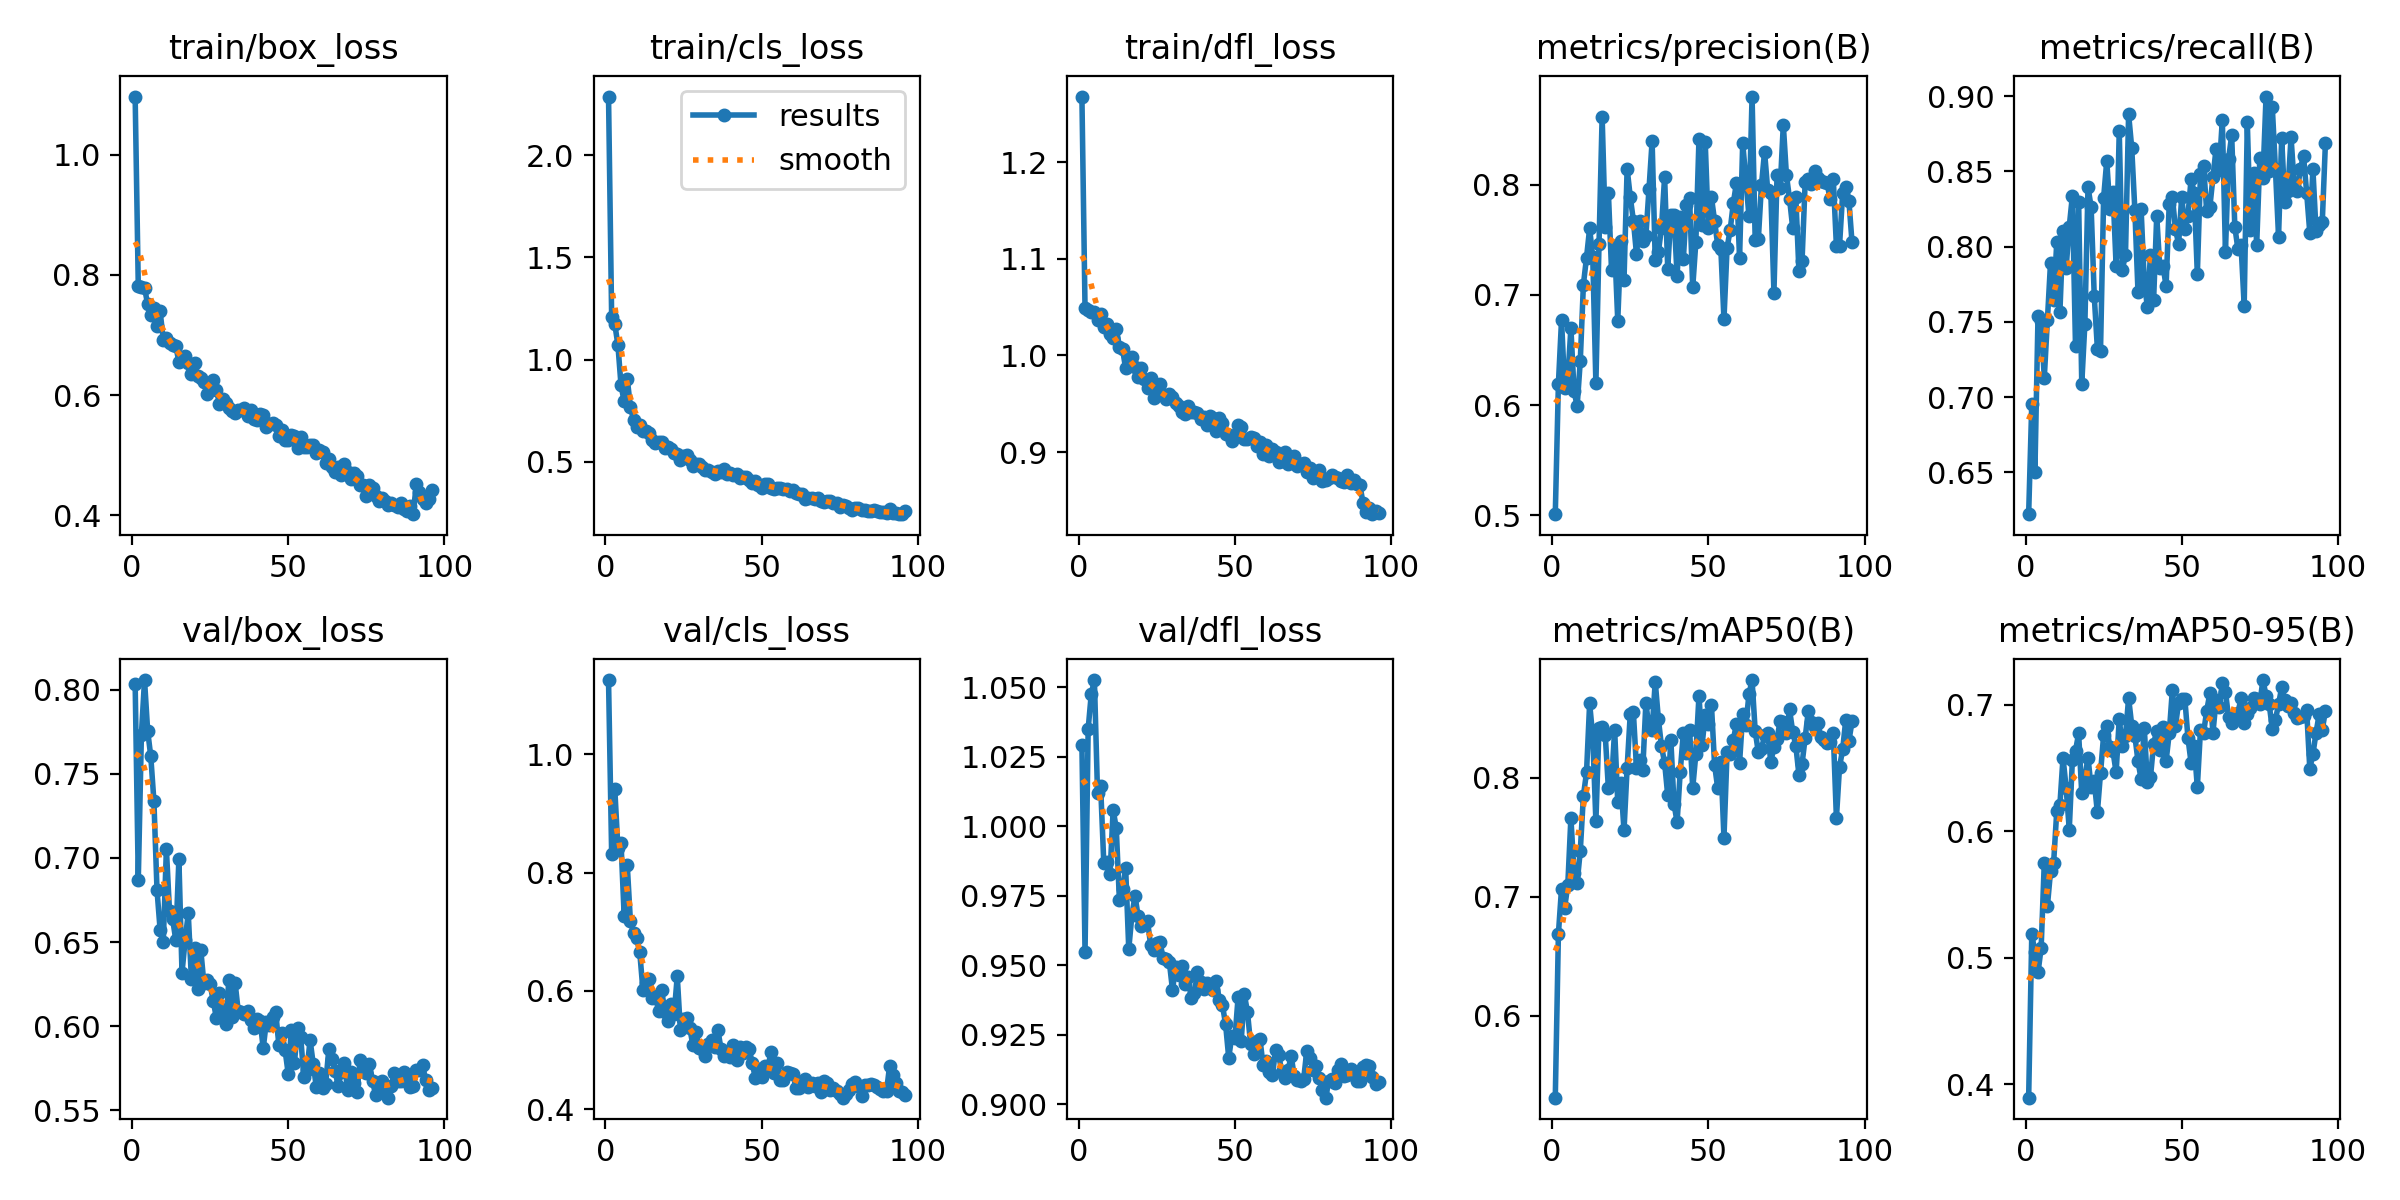

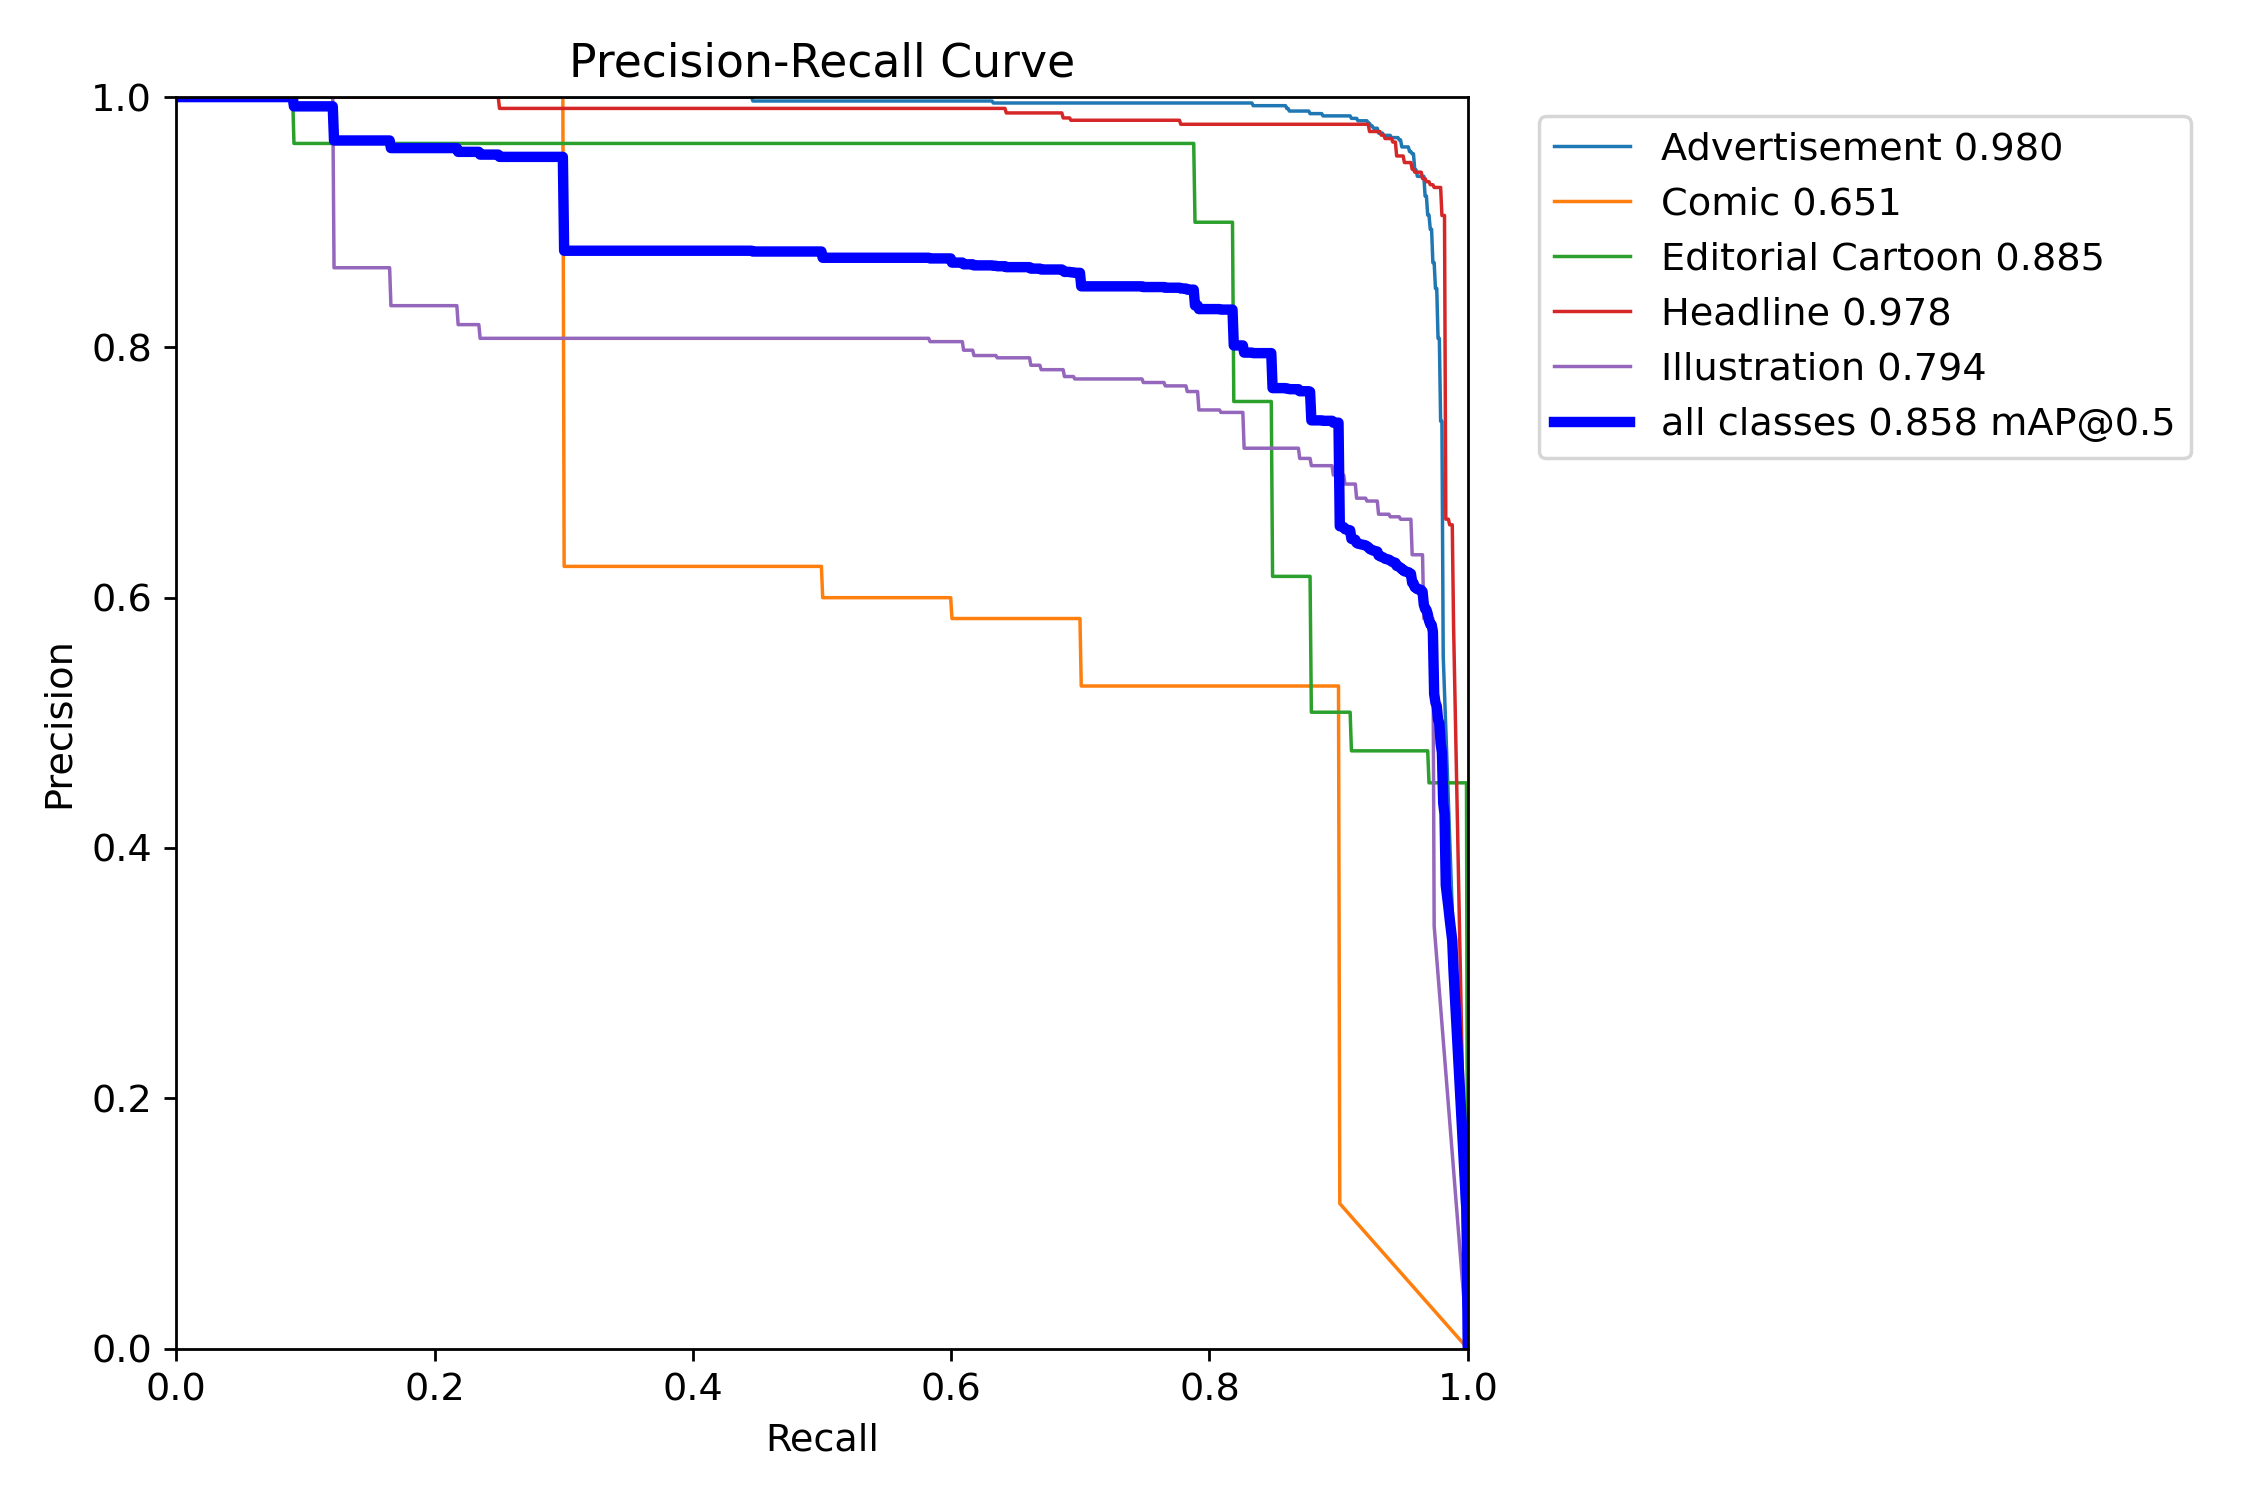

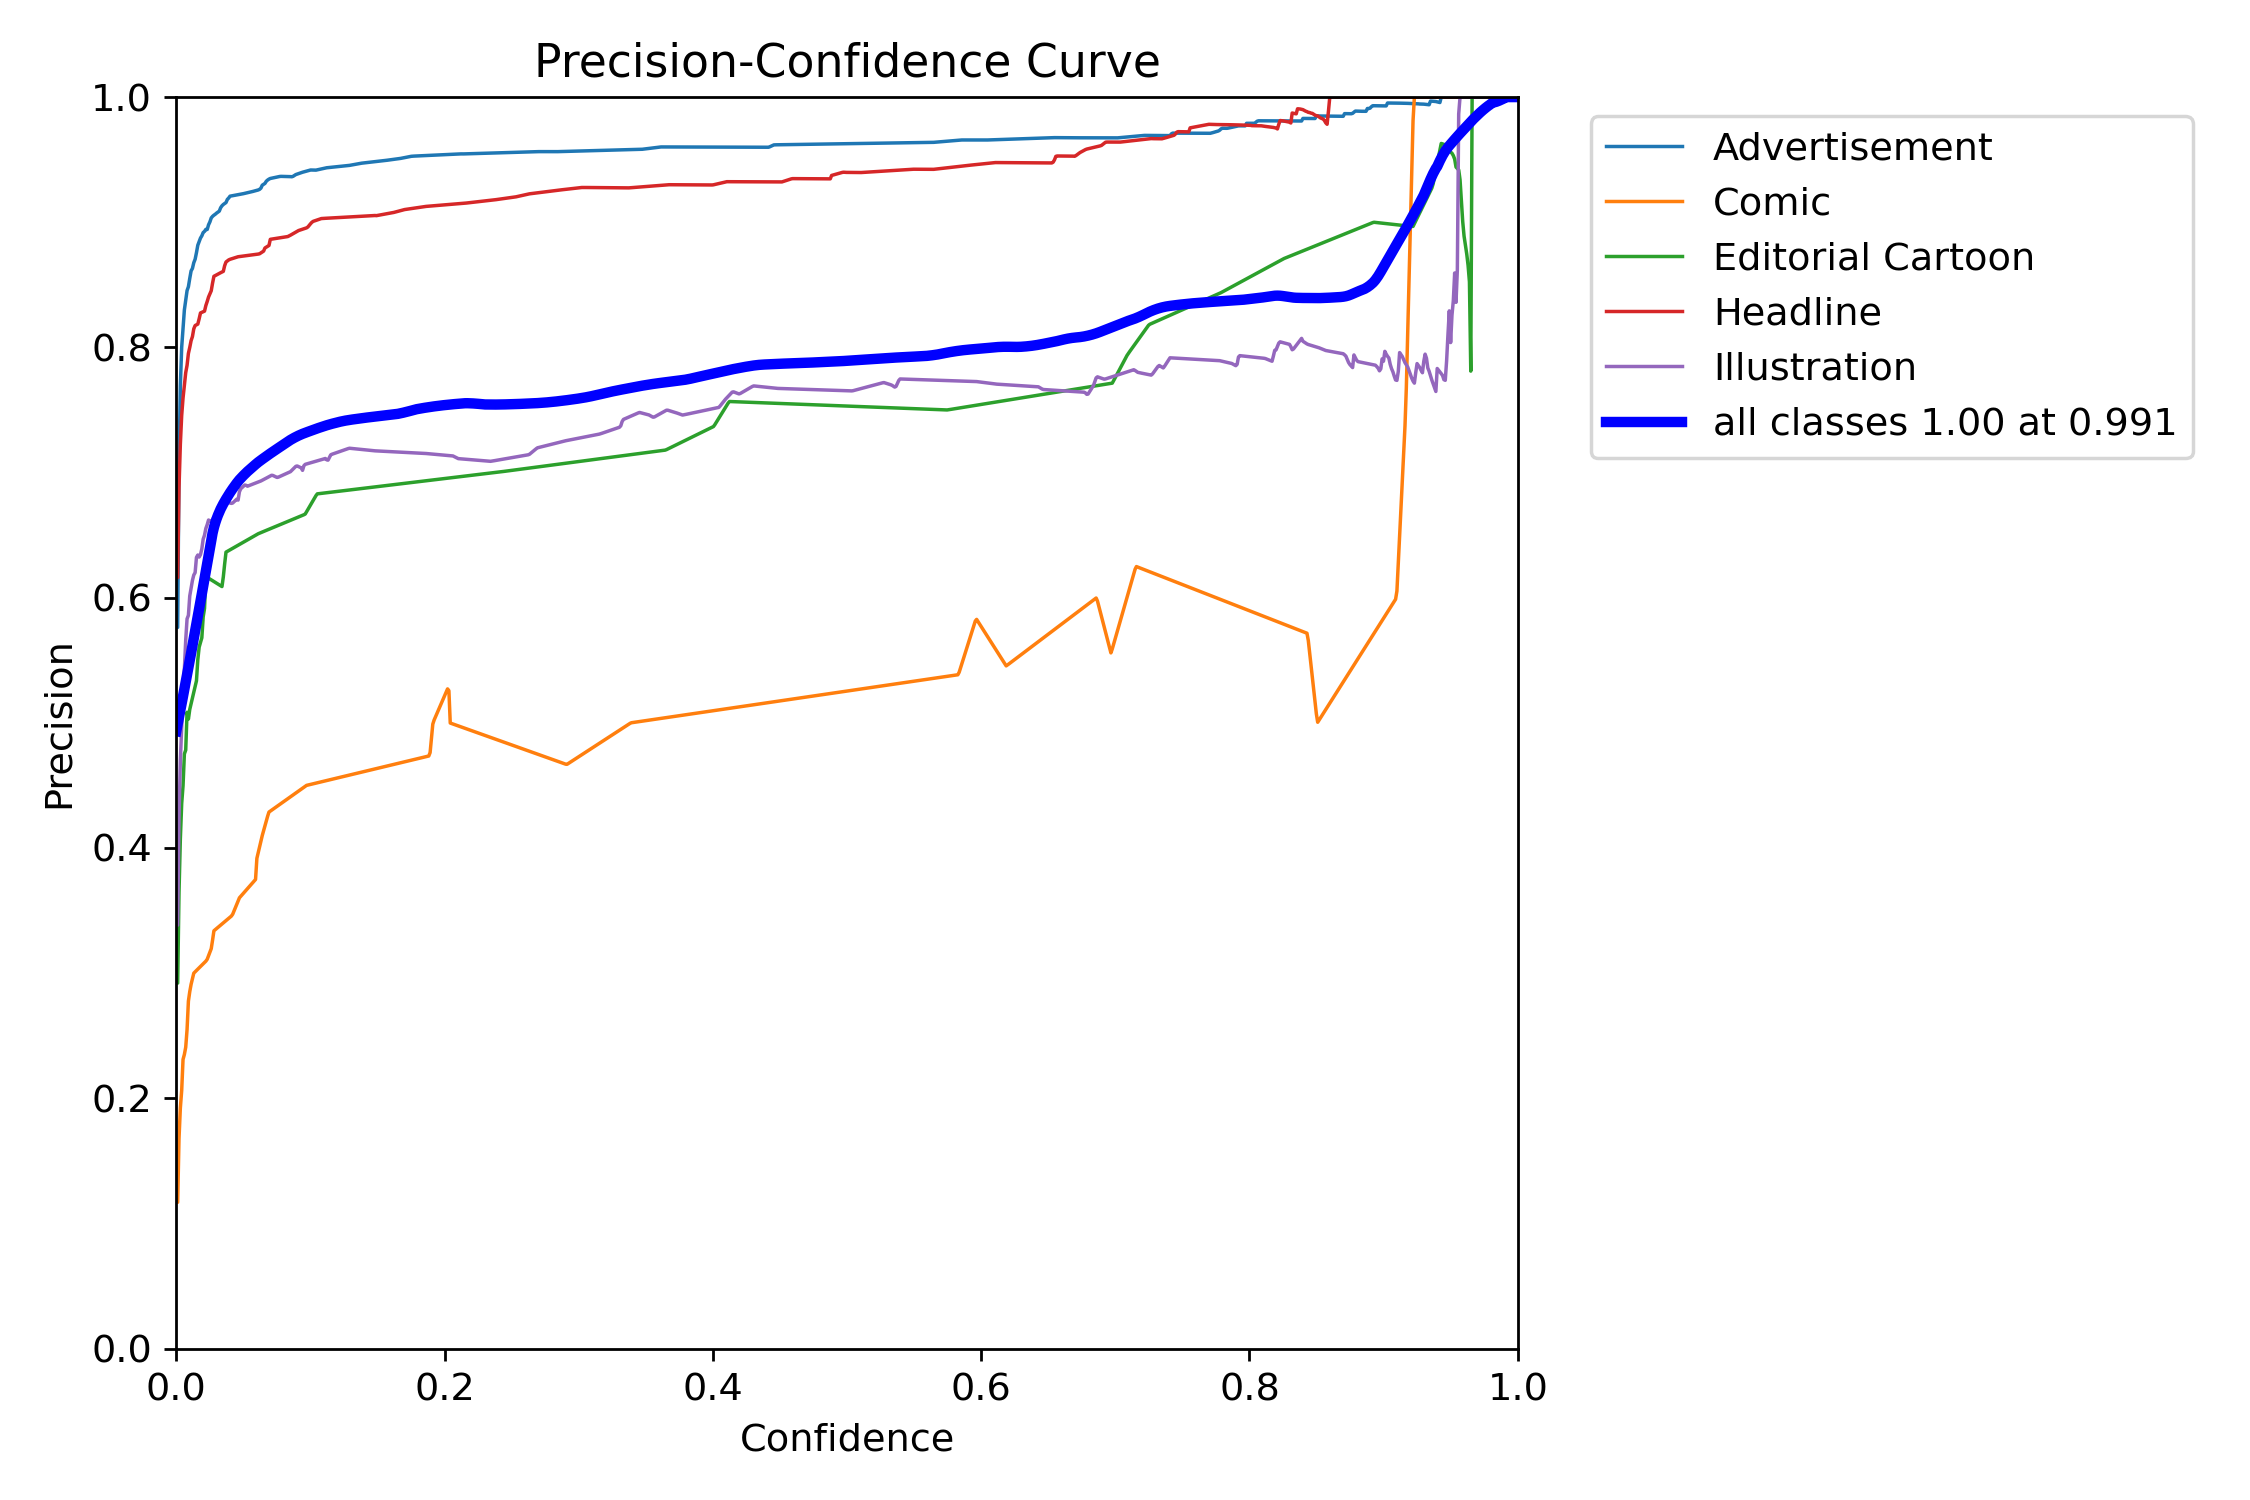

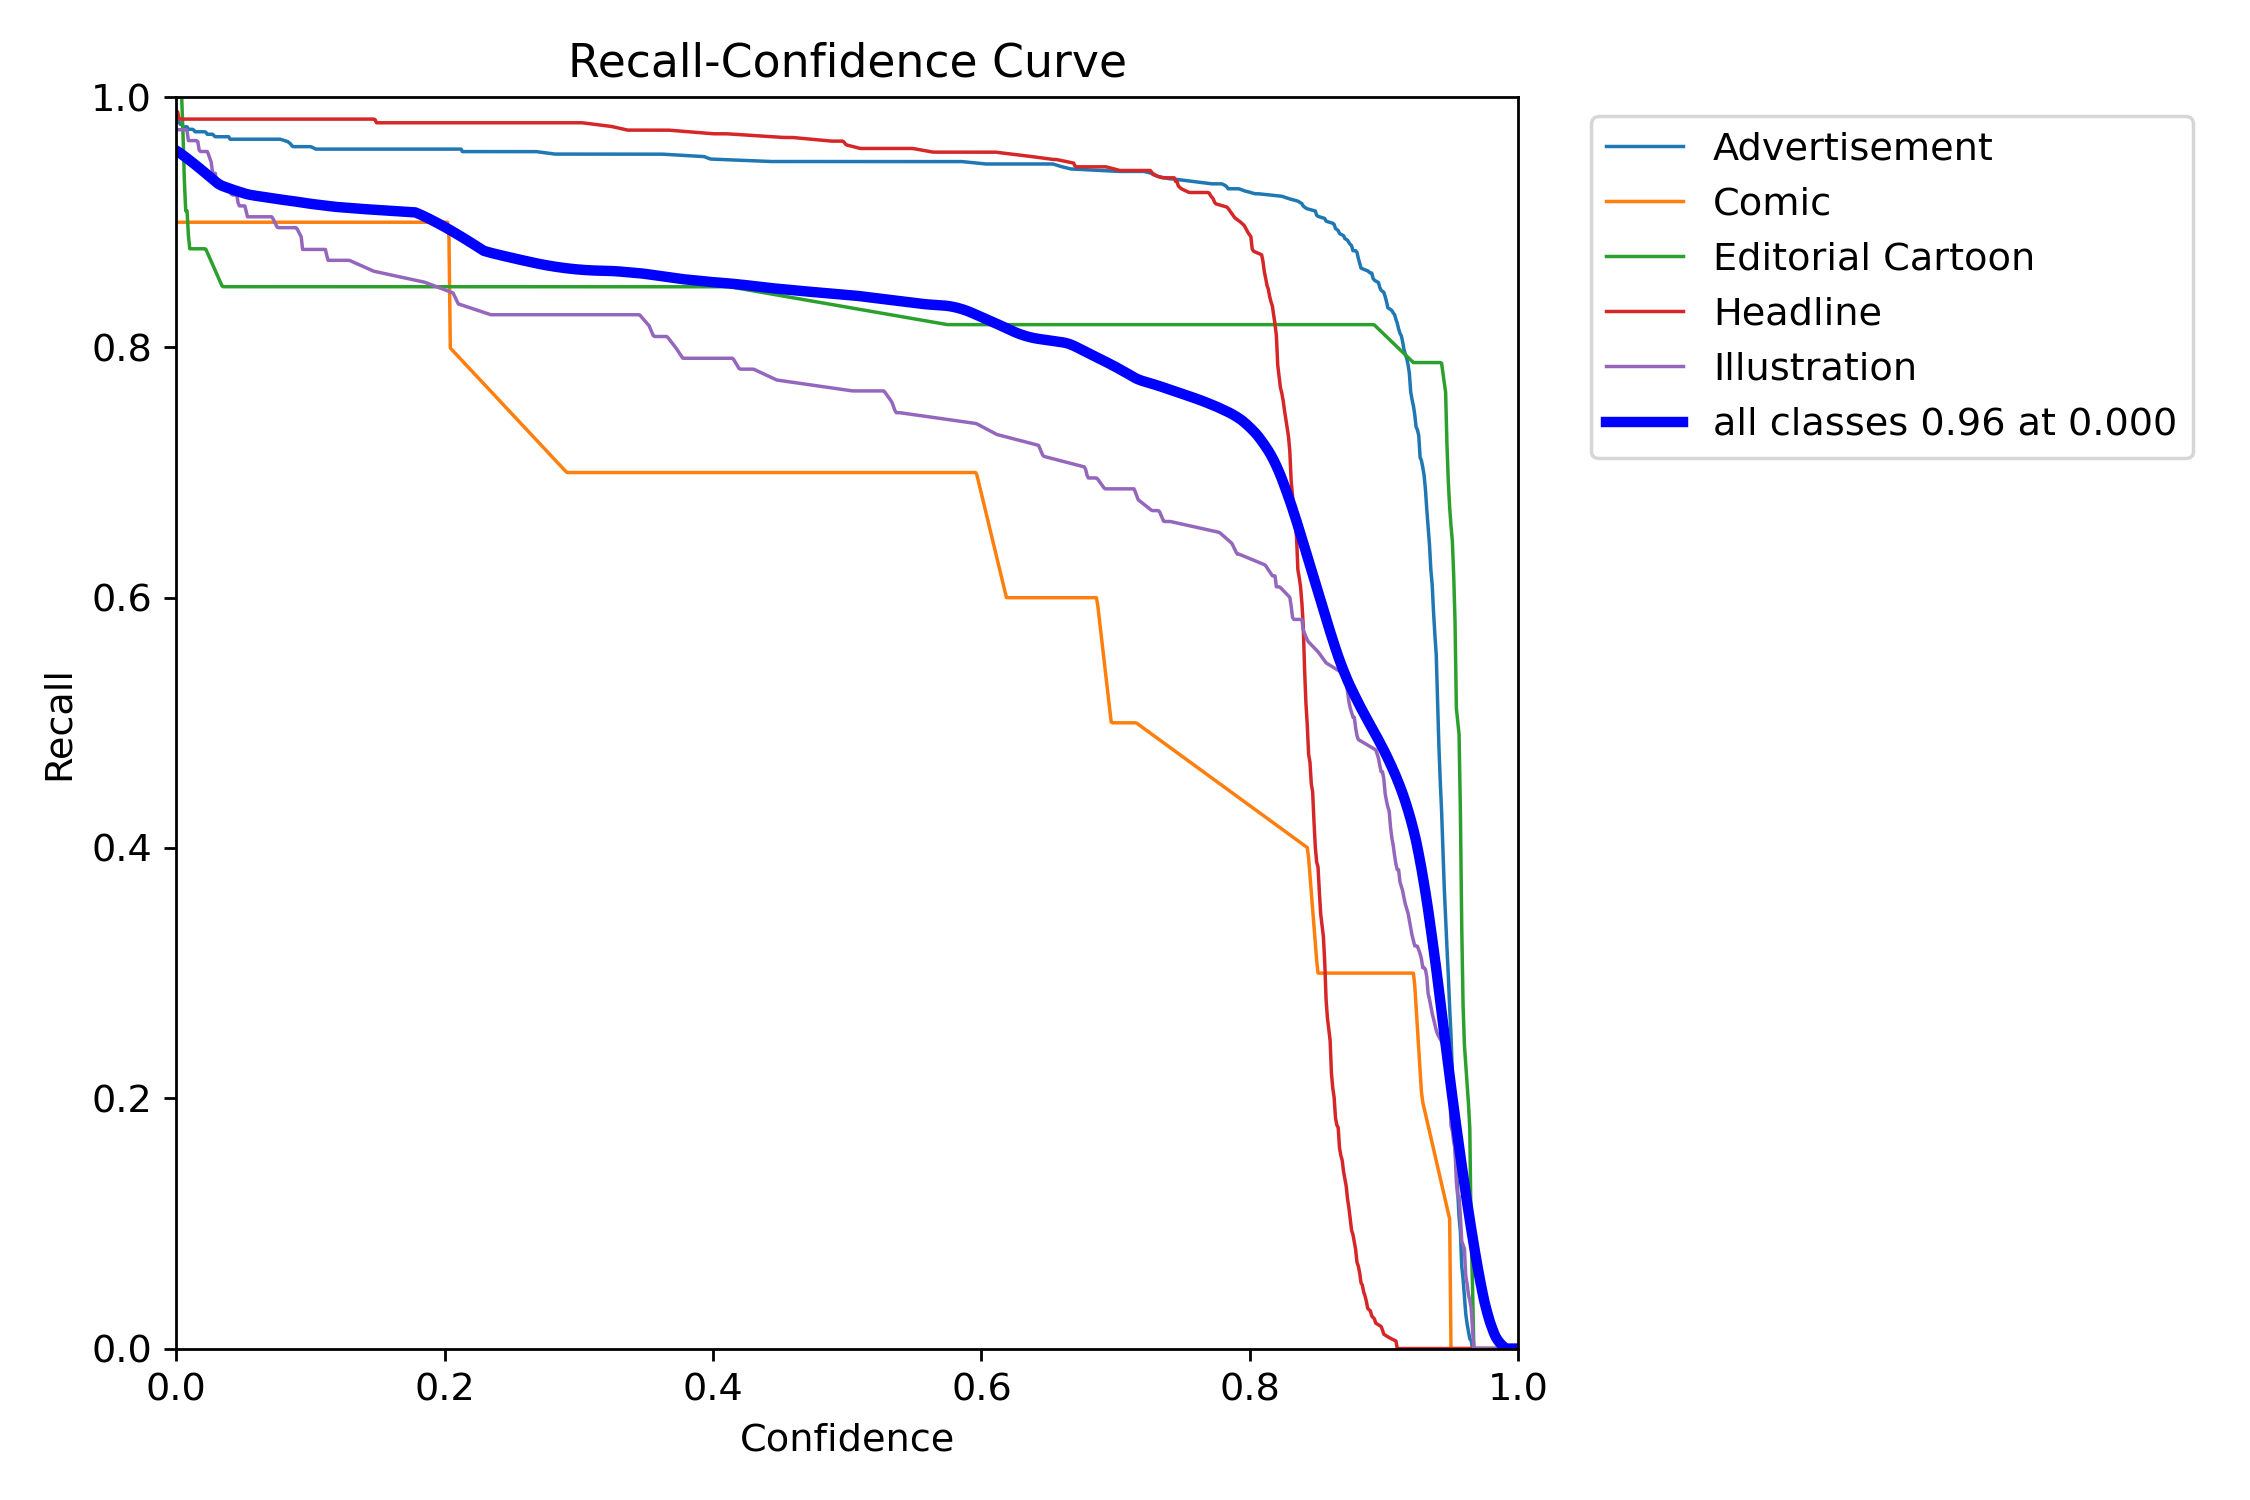

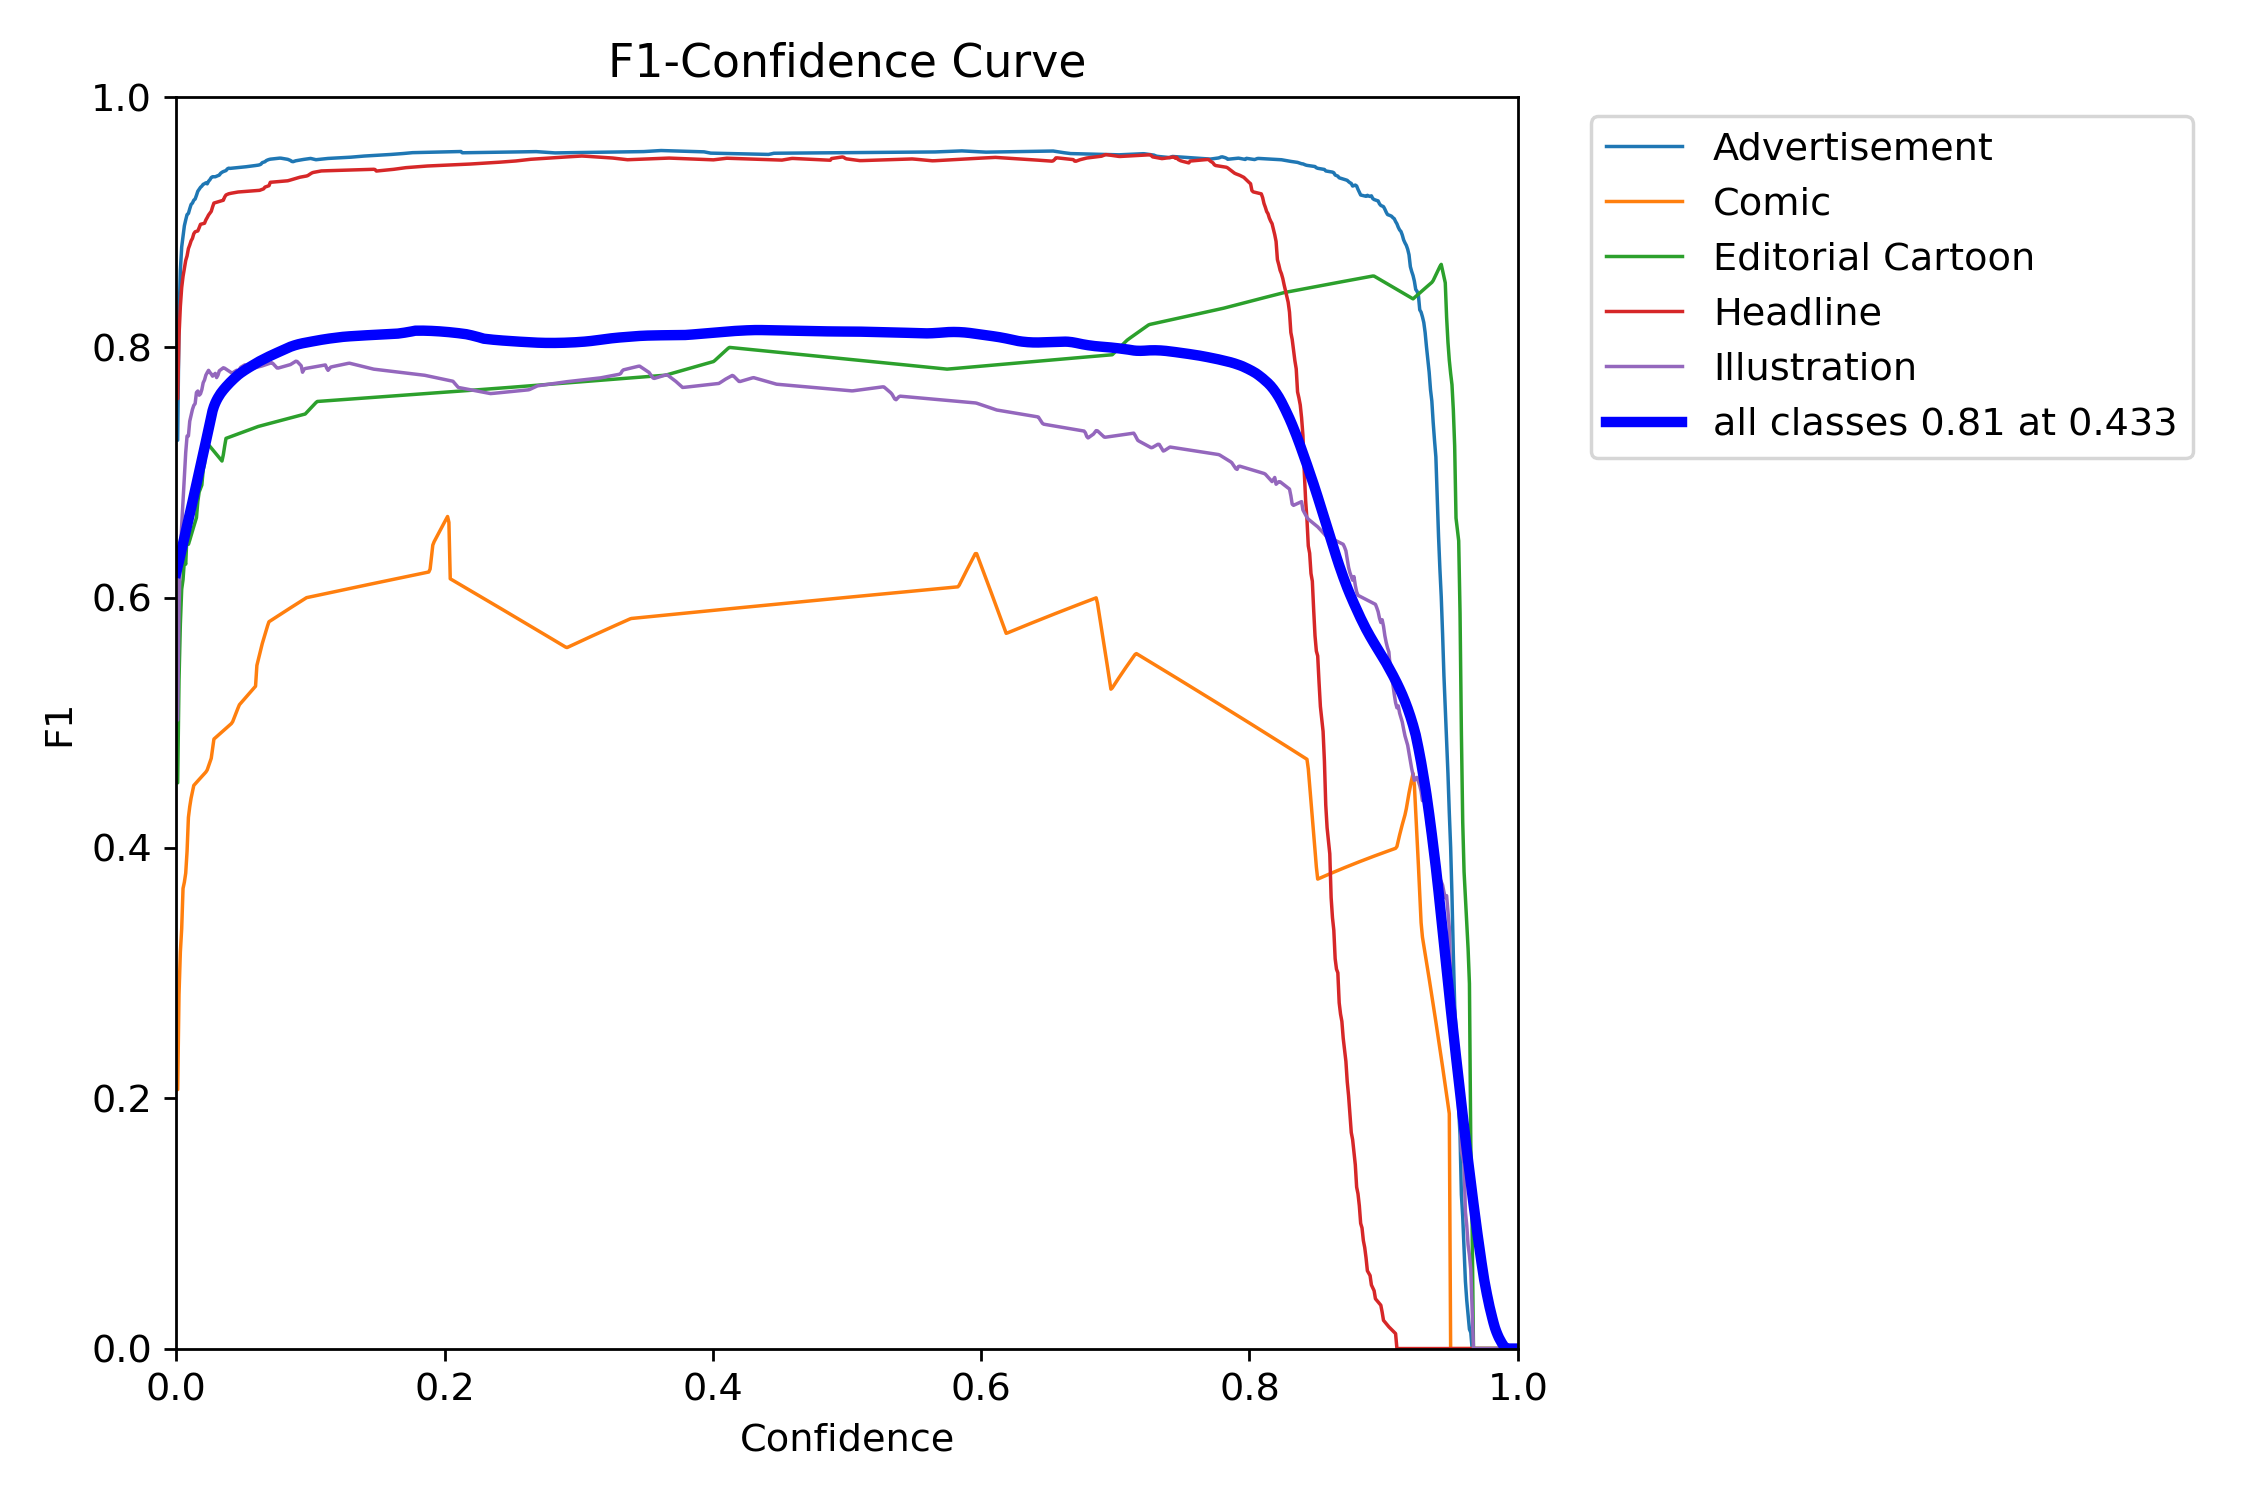

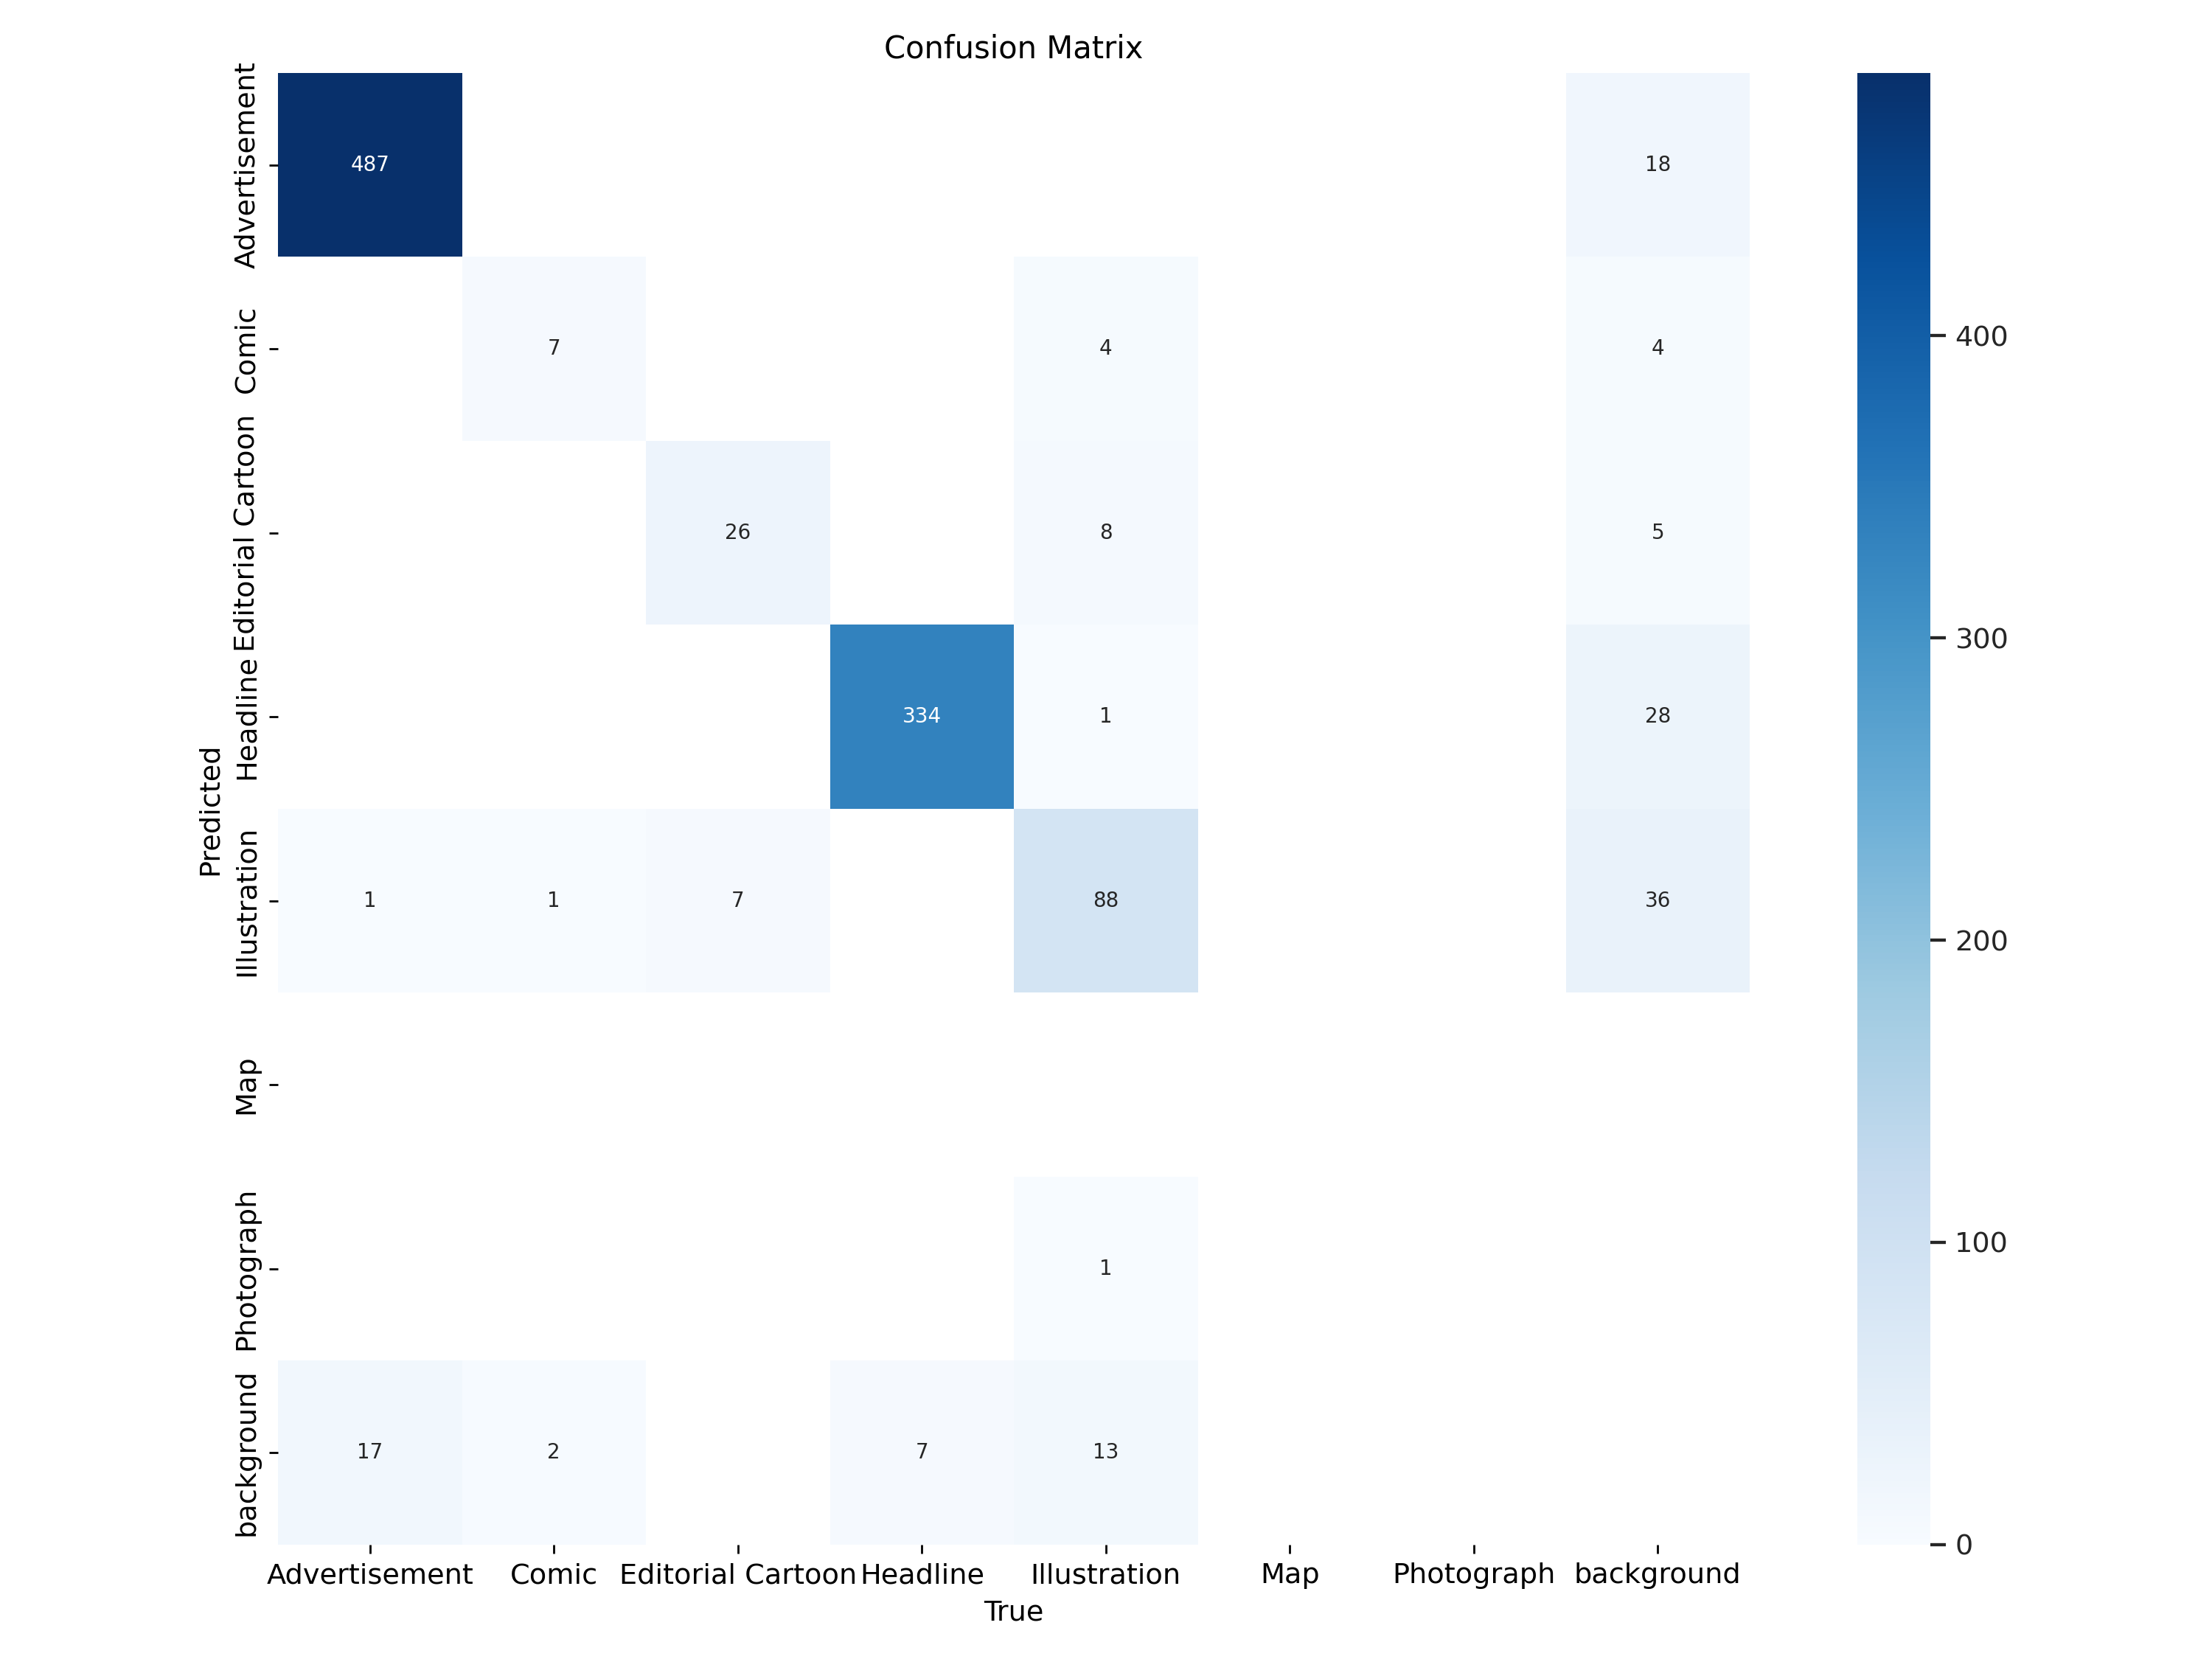

In [16]:
# Validate on the validation split and show the training curves
RUN_DIR = Path(PROJECT_DIR) / RUN_NAME
best_ckpt = RUN_DIR / "weights" / "best.pt"
last_ckpt = RUN_DIR / "weights" / "last.pt"

# If 'model' isn't in memory (e.g., after a runtime restart), load best.pt for evaluation
if "model" not in globals():
    assert best_ckpt.exists(), f"best.pt not found at {best_ckpt}"
    model = YOLO(str(best_ckpt))

metrics = model.val(
    data=CFG["data"],
    split="val",
    batch=BATCH,
    device=0 if torch.cuda.is_available() else "cpu",
    project=PROJECT_DIR,
    name=f"{RUN_NAME}_val"
)
print(metrics)

plots = ["results.png", "PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png", "confusion_matrix.png"]
for p in plots:
    fp = RUN_DIR / p
    if fp.exists():
        display(Image(filename=str(fp)))


## 9) Predict on a Folder of Pages (visual sanity check)

In [17]:
# Predict on a folder of pages (visual sanity check)
RUN_DIR = Path(PROJECT_DIR) / RUN_NAME
best_ckpt = RUN_DIR / "weights" / "best.pt"

if "model" not in globals():
    assert best_ckpt.exists(), f"best.pt not found at {best_ckpt}"
    model = YOLO(str(best_ckpt))

TEST_FOLDER = f"{DATASET_DIR}/images/val"  # change to any folder of images

pred = model.predict(
    source=TEST_FOLDER,
    conf=0.25,
    iou=0.6,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    save=True,
    project=PROJECT_DIR,
    name=f"{RUN_NAME}_preds"
)
pred[:2]



image 1/106 /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset/images/val/Die-Bombe_issue-bom18711001_1871-10-01_canvas-1.png: 1280x864 1 Headline, 2 Illustrations, 86.8ms
image 2/106 /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset/images/val/Die-Bombe_issue-bom18711001_1871-10-01_canvas-10.png: 1280x864 4 Advertisements, 71.8ms
image 3/106 /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset/images/val/Die-Bombe_issue-bom18711001_1871-10-01_canvas-2.png: 1280x864 5 Headlines, 1 Illustration, 86.1ms
image 4/106 /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset/images/val/Die-Bombe_issue-bom18711001_1871-10-01_canvas-3.png: 1280x864 5 Headlines, 2 Illustrations, 86.0ms
image 5/106 /content/drive/MyDrive/Masterarbeit_DH/Pipeline_BC/Models/training_dataset/images/val/Die-Bombe_issue-bom18711001_1871-10-01_canvas-4.png: 1280x864 1 Comic, 5 Headlines, 1 Illustration, 86.1ms
image 6/106 /conten

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Advertisement', 1: 'Comic', 2: 'Editorial Cartoon', 3: 'Headline', 4: 'Illustration', 5: 'Map', 6: 'Photograph'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [  0,   0,   0],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [  0,   0,   0],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [  0,   0,   0],
         [  0,   0,   0]],
 
      

## 11) (Optional) Tiled Inference for Small Illustrations
Use this helper to tile large pages into overlapping patches, run YOLO on each, and merge detections with NMS. Adjust `tile_size`/`overlap` for your page resolution.

In [ ]:

import cv2, math
import numpy as np
from ultralytics.utils import ops

def yolo_tile_infer(model, image_path, conf=0.25, iou=0.6, imgsz=1280, tile_size=1280, overlap=0.20):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    stride = int(tile_size * (1 - overlap))
    boxes_all, scores_all, cls_all = [], [], []

    for y0 in range(0, max(h - tile_size + 1, 1), stride):
        for x0 in range(0, max(w - tile_size + 1, 1), stride):
            y1 = min(y0 + tile_size, h)
            x1 = min(x0 + tile_size, w)
            tile = img[y0:y1, x0:x1]

            res = model.predict(source=tile, imgsz=imgsz, conf=conf, iou=iou, verbose=False, device=0 if torch.cuda.is_available() else 'cpu')
            if len(res) == 0:
                continue
            r = res[0]
            if r.boxes is None or r.boxes.data is None or len(r.boxes) == 0:
                continue

            b = r.boxes.xyxy.cpu().numpy()
            s = r.boxes.conf.cpu().numpy()
            c = r.boxes.cls.cpu().numpy()

            # shift boxes to global coords
            b[:, [0,2]] += x0
            b[:, [1,3]] += y0

            boxes_all.append(b)
            scores_all.append(s)
            cls_all.append(c)

    if not boxes_all:
        return np.empty((0,4)), np.empty((0,)), np.empty((0,))

    boxes_all = np.concatenate(boxes_all, axis=0)
    scores_all = np.concatenate(scores_all, axis=0)
    cls_all = np.concatenate(cls_all, axis=0)

    # NMS per class
    dets = np.hstack([boxes_all, scores_all[:,None]]).astype(np.float32)
    keep = ops.non_max_suppression(torch.from_numpy(dets[None, ...]), iou_thres=iou, conf_thres=conf, classes=None)[0]
    if keep is None or len(keep) == 0:
        return np.empty((0,4)), np.empty((0,)), np.empty((0,))

    keep = keep.cpu().numpy()
    final_boxes = keep[:, :4]
    final_scores = keep[:, 4]
    # Note: ops.nms result loses class; simple heuristic: keep class of nearest original box
    final_classes = []
    for fb in final_boxes:
        ious = ops.box_iou(torch.from_numpy(fb[None, :]), torch.from_numpy(boxes_all)).numpy()[0]
        idx = int(np.argmax(ious))
        final_classes.append(cls_all[idx])
    return final_boxes, final_scores, np.array(final_classes)

# Example:
# img_path = f"{DATASET_DIR}/images/val/some_page.jpg"
# boxes, scores, classes = yolo_tile_infer(best_model, img_path, imgsz=IMGSZ, tile_size=1280, overlap=0.2)
# print(len(boxes), "detections")
